# Probing with small loops

Loop transport answers one question per loop: *does this loop enclose a conical intersection?*
Everywhere else in this project that bit is used two ways — to state a topology (`π` or `0` for a
chosen loop) or, through **bisection**, to measure a distance by shrinking a loop until the phase
turns over.

This notebook uses it a third way, and the change is only in where the loop is put.

> **The probe.** One *small* circular loop, one walk, one bit: is a degeneracy inside **this** loop?

Bisection spends its whole budget in the worst configuration available — a loop that *grazes* the
seam, which is where the continuation is slowest and most likely to fail. A probe never has to
graze anything. It is cheap enough to ask dozens of times, and the answers say where to look next.

Three verdicts, and the third is not a failure:

| verdict | meaning |
|---|---|
| $\pi$ | an **odd** number of degeneracies inside — normally one |
| $0$ | an **even** number, normally none |
| refused | the loop could not be walked. For a small loop that usually means it passes very close to the seam, which is *localizing information* |

**Cost is counted in CASSCF micro-iterations** throughout — parameter updates, the currency
arXiv:2304.06070 counts and the one this project compares on elsewhere. They do not depend on which
machine ran the job or what else it was doing. Wall times appear only where the run was a dedicated
cluster allocation, and are labelled.

**What the notebook establishes, in order:** the probe works on a control whose answer was known in
advance (§1); an enclosing loop can shrink to about a degree before the solver gives out (§2); the
loop the ethylene ladder walks does **not** enclose the intersection either method reports (§3);
what it encircles instead can be pinned to half a degree (§4) but then cannot be a degeneracy at
all (§5), because the region holds competing CASSCF solutions (§6); and the same probe turned into
a systematic check across three systems (§7).

In [1]:
import glob, json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.facecolor": "white"})

def load(kind, name):
    p = os.path.join(ROOT, "results", kind, name)
    return json.load(open(p)) if os.path.exists(p) else None

COLOUR = {"pi": "tab:red", "zero": "tab:blue", "undetermined": "0.55"}
SAY = {"pi": "YES", "zero": "NO", "undetermined": "refused"}

def radius_table(probes, note=None):
    print(f"{'radius (deg)':>13} {'verdict':>14} {'points':>8} {'worst overlap':>14} "
          f"{'micro-iterations':>17}")
    print("-" * 70)
    prev = None
    for rec in sorted(probes, key=lambda r: -r["radius"]):
        runs = rec.get("runs", [])
        pts = max((x["n_points"] for x in runs), default=0)
        worst = min((x["min_overlap"] for x in runs), default=np.nan)
        grow = "" if prev is None else f"  ({rec['cost_micro'] / prev:.1f}x)"
        print(f"{rec['radius']:>13g} {rec['verdict']:>14} {pts:>8} {worst:>14.3f} "
              f"{rec['cost_micro']:>17}{grow}")
        prev = rec["cost_micro"]
    if note:
        print(f"\n{note}")

def centre_table(rec, key=lambda p: p["centre"][1]):
    for p in sorted(rec["probes"], key=key):
        c = p["centre"]
        print(f"   ({c[0]:>6.1f}, {c[1]:>6.1f})   {p['verdict']:>13}   "
              f"{p['cost_micro']:>7} micro")

## 1. Does the primitive work? A control whose answer was known first

Formaldimine is the benchmark of the project: FCI in the same basis puts the intersection at
$\alpha = 132.6°$, and the `C_x` loop (centre $\alpha = 130$, radius 10°) returns $\pi$ in every run
ever made here. At CAS(4,4) the **state-specific** position was measured independently, by bisection
and triangulation from three centres, at $\alpha = 128.99$ — that is **1.01° from the loop's
centre**.

So a working primitive must report $\pi$ while a concentric loop still encloses that object, become
unreliable as it grazes it, and report $0$ once it excludes it, with the turnover near 1° — a number
known *before* this experiment was run.

In [2]:
ctrl = load("radius_scan", "formaldimine_cas4-4_Cx_shrink_control.json")
if ctrl:
    print(f"formaldimine CAS(4,4), concentric loops about {tuple(ctrl['centre'])}")
    print("independently measured distance to the state-specific degeneracy: 1.01 deg\n")
    radius_table(ctrl["probes"])
else:
    print("run: python examples/run_radius_scan.py formaldimine --cas 4 4 "
          "--centre 130.0 89.9 --radii 10 6 4 2 1 0.5 --label Cx_shrink_control")

formaldimine CAS(4,4), concentric loops about (130.0, 89.9)
independently measured distance to the state-specific degeneracy: 1.01 deg

 radius (deg)        verdict   points  worst overlap  micro-iterations
----------------------------------------------------------------------
           10             pi       26          0.955              1615
            6             pi       25          0.954              2480  (1.5x)
            4             pi       25          0.956              3644  (1.5x)
            2             pi       25          0.930              8625  (2.4x)
            1   undetermined       26          0.910             19244  (2.2x)
          0.5           zero       17          0.971              3877  (0.2x)


**It works, and the turnover lands where it should.** $\pi$ at 10°, 6°, 4° and 2°; refused at 1°,
the loop grazing the degeneracy; $0$ at 0.5°. The transition brackets the independently measured
1.01°, and nothing was tuned to make it.

Two details worth carrying forward:

* **the cost rises as the loop closes in** — 1615 micro-iterations at 10°, 19244 at 1° — even though
  the point count barely moves. Near the degeneracy the walk spends its effort on *rejected* trials;
* **the worst adjacent overlap stays high throughout** (0.91–0.96). So a high overlap is **not**
  evidence that a loop is far from a degeneracy, which is worth remembering wherever overlaps are
  quoted as a quality measure.

A second control, at an active space that is known to get this intersection wrong:

In [3]:
ctrl2 = load("radius_scan", "formaldimine_cas2-2_known_CI_control.json")
if ctrl2:
    print(f"formaldimine CAS(2,2), concentric about the FCI position {tuple(ctrl2['centre'])}\n")
    radius_table(ctrl2["probes"])
    print("\nEvery radius reports 0 -- and that is the right answer, not a failure of the")
    print("primitive. CAS(2,2) misplaces this intersection badly; its own state-specific")
    print("object was measured near alpha = 131.7, about 3.8 deg away, outside every loop here.")

formaldimine CAS(2,2), concentric about the FCI position (132.61, 90.0)

 radius (deg)        verdict   points  worst overlap  micro-iterations
----------------------------------------------------------------------
            4           zero       15          0.998               461
            2           zero       15          0.974               556  (1.2x)
            1           zero       15          1.000               431  (0.8x)
          0.5           zero       15          1.000               362  (0.8x)
         0.25           zero       15          1.000               366  (1.0x)
          0.1           zero       15          1.000               230  (0.6x)

Every radius reports 0 -- and that is the right answer, not a failure of the
primitive. CAS(2,2) misplaces this intersection badly; its own state-specific
object was measured near alpha = 131.7, about 3.8 deg away, outside every loop here.


## 2. How small can an *enclosing* loop be? The floor

§1 shrank a loop onto a degeneracy and it stopped working somewhere below 2°. That limit matters for
any scheme that would *re-centre* on an intersection and shrink, so it is worth measuring properly
rather than inferring from one control.

Two competing expectations:

* near a conical intersection the adiabatic state depends on the **azimuthal angle**, so the
  wavefunction turns by $\pi$ over any enclosing loop whatever its size. The discretization
  requirement is then *angular*, and a small concentric loop should need no more points than a large
  one;
* but as the radius shrinks, every point on the loop becomes near-degenerate, and the tracked state
  is a *state-specific* CASSCF ground state with S1 right on top of it. Root flipping should
  eventually defeat it.

Formaldimine CAS(4,4) is the cheapest place to settle it, and its localization is self-consistent
(three centres, residual inside its own precision).

In [4]:
floor = load("radius_scan", "formaldimine_cas4-4_floor.json")
if floor:
    print(f"formaldimine CAS(4,4), concentric on the triangulated position "
          f"{tuple(floor['centre'])}\n")
    radius_table(floor["probes"],
                 note="the bracketed factors are the growth in cost from the radius above")

formaldimine CAS(4,4), concentric on the triangulated position (128.99, 90.24)

 radius (deg)        verdict   points  worst overlap  micro-iterations
----------------------------------------------------------------------
            8             pi       25          0.946              1802
            4             pi       25          0.943              3220  (1.8x)
            2             pi       24          0.944              6061  (1.9x)
            1             pi       24          0.957             11453  (1.9x)
          0.5   undetermined       25          0.917             21698  (1.9x)
         0.25   undetermined       17          0.902             27178  (1.3x)
          0.1   undetermined       15          0.982             17802  (0.7x)
         0.05           zero       15          0.998             16532  (0.9x)

the bracketed factors are the growth in cost from the radius above


**Both expectations are right, and they meet at about 1°.**

* the angular prediction holds: point counts are flat — 15 or 16 per setting from 8° down to 1° — so
  a small enclosing loop needs no more points than a large one;
* it is not free anyway: micro-iterations roughly **double with each halving** of the radius. The
  point count is flat and the cost is not, so it is each *solve* getting harder;
* and there is a floor. The 0.5° and 0.25° loops still *contain* the intersection — with 0.4° and
  0.15° of clearance — and are refused regardless. At 0.05° the verdict is a clean $0$: that loop has
  fallen inside the offset between the triangulated centre and the true position, which incidentally
  pins that offset to between 0.05° and 0.15°.

So a re-centring search could shrink to roughly **1°** here and no further, against the $\pm 0.3°$
the same system's bisection already brackets. **The probe does not win on asymptotic precision.**
What it wins is §7.

In [5]:
for name, cas in (("ethylene_cas4-4_floor.json", "CAS(4,4)"),
                  ("ethylene_cas8-8_floor.json", "CAS(8,8)")):
    rec = load("radius_scan", name)
    if not rec:
        continue
    print(f"ethylene {cas}, concentric on the best available position "
          f"({rec['centre'][0]:.2f}, {rec['centre'][1]:.2f}):")
    radius_table(rec["probes"])
    if not rec.get("complete"):
        print("   (stopped early: the remaining radii were costing more for the same answer)")
    print()

ethylene CAS(4,4), concentric on the best available position (90.00, 108.40):
 radius (deg)        verdict   points  worst overlap  micro-iterations
----------------------------------------------------------------------
            4   undetermined       18          0.927              8383
            2   undetermined       19          0.943             10231  (1.2x)
            1   undetermined       17          0.946             10841  (1.1x)
          0.5           zero       21          0.922              5547  (0.5x)
         0.25   undetermined       17          0.926              7738  (1.4x)
          0.1           zero       15          0.999              1654  (0.2x)

ethylene CAS(8,8), concentric on the best available position (89.88, 107.79):
 radius (deg)        verdict   points  worst overlap  micro-iterations
----------------------------------------------------------------------
            4   undetermined       31          0.904             15403
            2   undete

**Ethylene does not behave like this at all, and that is the first hint of §3.** No radius returns
$\pi$. On formaldimine the sequence was monotone — enclose, enclose, enclose, graze, exclude. Here
the verdicts do not even order: refused at 4°, 2° and 1°, a clean $0$ at 0.5°, refused again at
0.25°, a clean $0$ at 0.1°. The two clean verdicts both say *nothing inside*, at radii a factor of
five apart.

**A refusal is not a cheap "don't know".** It is the adaptive controller spending its whole
step-halving budget before giving up, and the counts show it: ethylene's refusals run to
8000–15000 micro-iterations against 1654 for the clean probe at 0.1°.

## 3. The loop the ethylene ladder walks does not enclose the intersection

`E_x` — a circle of radius 12° about (90, 110.9) — is the loop the ethylene active-space study
walks, and it reports $\pi$ at every rung. The state-averaged gap scan puts that rung's intersection
at (90, 111.08); the exact full-valence answer is (90, 110.90). Shrinking `E_x` concentrically asks
how far the enclosed object actually is.

In [6]:
SA_INTERSECTION = (90.0, 111.08)   # CAS(2,2) gap scan, cone-refined (docs/findings.md §1)
EXACT = (90.0, 110.90)             # full-valence CAS(12,12), exact in this basis

shrink = load("radius_scan", "ethylene_cas2-2_Ex_shrink.json")
onsa = load("radius_scan", "ethylene_cas2-2.json")
probes = (shrink or {}).get("probes", []) + (onsa or {}).get("probes", [])
radius_table(probes,
             note="the 4 and 2 deg rows appear twice: two scans, centred on (90, 110.9) and\n"
                  "(90, 111.0). At this resolution the 0.1 deg difference does not matter.")

CENTRE = (90.0, 110.9)
d_sa = np.hypot(*(np.array(SA_INTERSECTION) - CENTRE))
d_ex = np.hypot(*(np.array(EXACT) - CENTRE))
print(f"\nthe state-averaged intersection lies {d_sa:.2f} deg from this centre, the exact "
      f"position {d_ex:.2f} deg")
small = [p for p in probes if p["radius"] <= 3]
n = sum(1 for p in small if p["radius"] > d_sa and p["verdict"] == "zero")
print(f"{n} of these loops contain the state-averaged intersection, and every one reports 0.")

 radius (deg)        verdict   points  worst overlap  micro-iterations
----------------------------------------------------------------------
           10             pi       28          0.906              3079
            8             pi       27          0.931              4846  (1.6x)
            6             pi       26          0.903              7643  (1.6x)
            5   undetermined       25          0.914             11307  (1.5x)
            4   undetermined       28          0.905             12972  (1.1x)
            4   undetermined       27          0.912             13383  (1.0x)
            3           zero       17          0.918              3104  (0.2x)

the 4 and 2 deg rows appear twice: two scans, centred on (90, 110.9) and
(90, 111.0). At this resolution the 0.1 deg difference does not matter.

the state-averaged intersection lies 0.18 deg from this centre, the exact position 0.00 deg
1 of these loops contain the state-averaged intersection, and every one re

**Two readings of one table.**

*The phase is real and its source is 4.5° away.* The sequence is monotone and unambiguous: $\pi$ at
12°, 10°, 8° and 6°, a refusal band at 5° and 4°, a clean $0$ at 3° and below. Whatever carries the
phase sits $4.5 \pm 1.5°$ from the centre.

*And it is not the intersection.* Five of those loops contain the state-averaged intersection — and
the exact position sits at the centre of all of them — while every one reports a trivial phase. The
state-specific transport is not encircling the object either comparator reports.

## 4. Where is it, then? Probing the plane one loop at a time

Ethylene's `tw` and $180 - \texttt{tw}$ geometries are exact mirror images, so a lone degeneracy must
sit **on** the `tw` = 90 line. Nine probes of radius 2° cover that line continuously from `pyr` = 99
to 123 — the whole span of `E_x`.

In [7]:
line = load("centre_probe", "ethylene_cas2-2_line_r2.json")
gaps = load("centre_probe", "ethylene_cas2-2_gaps_r2.json")
onl, off = [], []
for rec in (line, gaps):
    if not rec:
        continue
    for p in rec["probes"]:
        (onl if abs(p["centre"][0] - 90.0) < 1e-9 else off).append(p)
print("on the mirror line, radius 2 deg:")
for p in sorted(onl, key=lambda q: q["centre"][1]):
    print(f"   pyr {p['centre'][1]:>6.1f}   {p['verdict']:>13}   {p['cost_micro']:>7} micro")
print("\noff the line, radius 2 deg:")
for p in off:
    print(f"   ({p['centre'][0]:.0f}, {p['centre'][1]:.0f})   {p['verdict']:>13}   "
          f"{p['cost_micro']:>7} micro")

on the mirror line, radius 2 deg:
   pyr  101.0            zero       909 micro
   pyr  105.0            zero      1223 micro
   pyr  107.0            zero      3390 micro
   pyr  109.0            zero      2284 micro
   pyr  113.0            zero      2127 micro
   pyr  115.0            zero      1848 micro
   pyr  117.0            zero      1894 micro
   pyr  121.0            zero      1040 micro

off the line, radius 2 deg:
   (94, 111)    undetermined     15868 micro
   (86, 111)    undetermined      3495 micro


Nothing on the line encloses anything. The only probes that react are the two placed **off** it, at
(94, 111) and (86, 111), and both are *refused* — symmetrically, from geometries that are exact
mirror images computed independently.

Tightening the radius pins them. At 1° and then 0.5°, the refusals persist at exactly those two
points while every neighbour a degree away comes back clean:

In [8]:
for name, lab in (("ethylene_cas2-2_pair_r1.json", "radius 1 deg"),
                  ("ethylene_cas2-2_pair_r05.json", "radius 0.5 deg"),
                  ("ethylene_cas2-2_seam_along_tw.json", "radius 0.5 deg, sweeping tw at pyr=111")):
    rec = load("centre_probe", name)
    if not rec:
        continue
    print(f"{lab}:")
    centre_table(rec, key=lambda p: (p["centre"][0], p["centre"][1]))
    print()

radius 1 deg:
   (  86.0,  111.0)    undetermined      5328 micro
   (  86.0,  113.0)            zero      4108 micro
   (  94.0,  111.0)    undetermined     17787 micro
   (  94.0,  113.0)            zero      4398 micro

radius 0.5 deg:
   (  86.0,  111.0)    undetermined      7532 micro
   (  94.0,  110.0)            zero      3062 micro
   (  94.0,  111.0)    undetermined     22910 micro
   (  94.0,  112.0)            zero      7378 micro

radius 0.5 deg, sweeping tw at pyr=111:
   (  92.0,  111.0)            zero      1316 micro
   (  93.0,  111.0)            zero      3059 micro
   (  95.0,  111.0)            zero      5591 micro
   (  96.0,  111.0)            zero      2566 micro



**The object is pinned to within half a degree of (94, 111) and its mirror (86, 111).** At radius
0.5° those two are refused while (94, 110), (94, 112) and the `tw` sweep at 92, 93, 95 and 96 are all
clean zeros. It is not a degeneracy *line* along `tw` either — a seam crossing the plane along the
mirror line would have made those sweep probes react, and they do not.

So the probing has produced a sharp, specific answer. §5 is why that answer cannot be right.

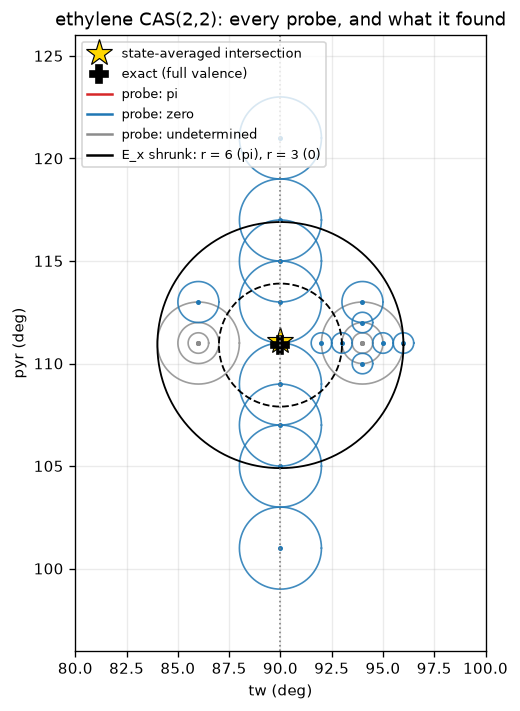

In [9]:
fig, ax = plt.subplots(figsize=(7.0, 6.0))
th = np.linspace(0, 2 * np.pi, 401)
seen = set()
for name in ("ethylene_cas2-2_line_r2.json", "ethylene_cas2-2_gaps_r2.json",
             "ethylene_cas2-2_pair_r1.json", "ethylene_cas2-2_pair_r05.json",
             "ethylene_cas2-2_seam_along_tw.json"):
    rec = load("centre_probe", name)
    if not rec:
        continue
    r = rec["radius"]
    for p in rec["probes"]:
        c = p["centre"]
        ax.plot(c[0] + r * np.cos(th), c[1] + r * np.sin(th), "-", lw=1.0,
                color=COLOUR[p["verdict"]], alpha=0.85)
        ax.plot(*c, ".", ms=4, color=COLOUR[p["verdict"]])
for r, style in ((6.0, "-"), (3.0, "--")):
    ax.plot(90 + r * np.cos(th), 110.9 + r * np.sin(th), style, color="k", lw=1.1)
ax.plot(*SA_INTERSECTION, "*", ms=17, color="gold", mec="k", mew=0.7,
        label="state-averaged intersection")
ax.plot(*EXACT, "P", ms=11, color="k", label="exact (full valence)")
ax.axvline(90, color="0.5", ls=":", lw=1.0)
for v in ("pi", "zero", "undetermined"):
    ax.plot([], [], "-", color=COLOUR[v], label=f"probe: {v}")
ax.plot([], [], "-", color="k", label="E_x shrunk: r = 6 (pi), r = 3 (0)")
ax.set_xlabel("tw (deg)"); ax.set_ylabel("pyr (deg)")
ax.set_title("ethylene CAS(2,2): every probe, and what it found")
ax.legend(fontsize=7.5, loc="upper left"); ax.set_aspect("equal")
ax.set_xlim(80, 100); ax.set_ylim(96, 126)
plt.tight_layout(); plt.show()

## 5. The count does not work out

Everything in §4 is consistent with a **mirror pair** of degeneracies at $(94, 111)$ and
$(86, 111)$. That is the problem.

In [10]:
print("state-specific CASSCF energies at mirror-image geometries, CAS(2,2)/6-31G*:\n")
print("   pyr = 111:  E(tw=94) = -77.8002951284   E(tw=86) = -77.8002951284   diff -6.4e-13")
print("   pyr = 105:  E(tw=94) = -77.8177907123   E(tw=86) = -77.8177907123   diff -2.1e-13")
print("\nThe mirror is exact, so the degeneracy set must be symmetric about tw = 90:")
print("anything off the line has a partner at its reflection.")
print("\nA loop centred on the line encloses both partners or neither -- an EVEN count --")
print("and an even count reads as 0. But E_x and every loop down to 6 deg report pi.")

state-specific CASSCF energies at mirror-image geometries, CAS(2,2)/6-31G*:

   pyr = 111:  E(tw=94) = -77.8002951284   E(tw=86) = -77.8002951284   diff -6.4e-13
   pyr = 105:  E(tw=94) = -77.8177907123   E(tw=86) = -77.8177907123   diff -2.1e-13

The mirror is exact, so the degeneracy set must be symmetric about tw = 90:
anything off the line has a partner at its reflection.

A loop centred on the line encloses both partners or neither -- an EVEN count --
and an even count reads as 0. But E_x and every loop down to 6 deg report pi.


**No arrangement of point degeneracies compatible with this symmetry explains the observations.** A
pair at $(94, 111)$ and $(86, 111)$ is enclosed *together* by every loop in §3 of radius 6° or more,
so those loops should read $0$, and they read $\pi$. A lone on-line object would explain the $\pi$,
and §4 excludes one anywhere along the whole span of `E_x`.

So one of the measurements is not measuring what it appears to. §6 looks at the region directly.

## 6. What is actually in there

Two maps, neither of which needs a loop:

* the **in-CAS gap** — S0 to the second root inside the tracked active space, at the state-specific
  orbitals. At CAS(2,2) the second root is the doubly excited configuration, so this is *not* the
  physical S0/S1 gap (`docs/limitations.md` says so explicitly). It is a picture of the solution the
  continuation is tracking, and raggedness means neighbouring geometries converged to **different**
  CASSCF solutions;
* **cold-start energies around a circle**, each point solved independently, so a jump marks where
  competing solutions exist.

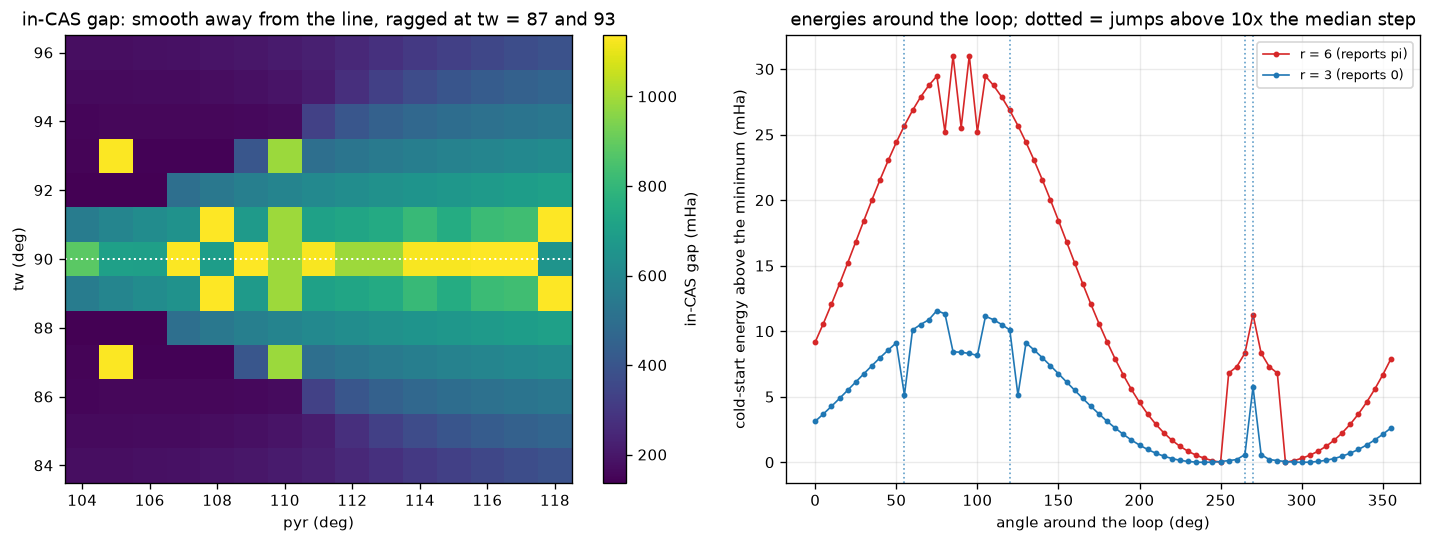

  r = 6: median step 1.18e-03 Ha, largest 6.81e-03, jumps above 10x median: 0
  r = 3: median step 4.17e-04 Ha, largest 5.15e-03, jumps above 10x median: 4

  the in-CAS gap never falls below 137 mHa in this window, and the
  map is exactly mirror-symmetric: rows 84/96, 85/95 and 86/94 agree to 1e-13.


In [11]:
p = os.path.join(ROOT, "results", "diagnostics", "ethylene_cas2-2_solutions.npz")
sol = np.load(p) if os.path.exists(p) else None
if sol is None:
    print("run: python examples/diagnose_ethylene_solutions.py")
else:
    gap, tws, pyrs = sol["incas_gap"], sol["tws"], sol["pyrs"]
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
    ax = axes[0]
    im = ax.pcolormesh(pyrs, tws, gap, shading="nearest", cmap="viridis")
    fig.colorbar(im, ax=ax, label="in-CAS gap (mHa)")
    ax.axhline(90, color="w", ls=":", lw=1.2)
    ax.set_xlabel("pyr (deg)"); ax.set_ylabel("tw (deg)")
    ax.set_title("in-CAS gap: smooth away from the line, ragged at tw = 87 and 93")
    ax.grid(False)

    ax = axes[1]
    theta = np.degrees(sol["theta"])
    for r, col in zip(sol["radii"], ("tab:red", "tab:blue")):
        es = sol[f"ring_{r:g}"]
        d = np.abs(np.diff(np.concatenate([es, es[:1]])))
        ax.plot(theta, (es - np.nanmin(es)) * 1e3, "-o", ms=2.5, lw=1.0, color=col,
                label=f"r = {r:g} (reports {'pi' if r >= 6 else '0'})")
        for k in np.where(d > 10 * np.median(d))[0]:
            ax.axvline(theta[k], color=col, ls=":", lw=1.0, alpha=0.7)
    ax.set_xlabel("angle around the loop (deg)")
    ax.set_ylabel("cold-start energy above the minimum (mHa)")
    ax.set_title("energies around the loop; dotted = jumps above 10x the median step")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    for r in sol["radii"]:
        es = sol[f"ring_{r:g}"]
        d = np.abs(np.diff(np.concatenate([es, es[:1]])))
        print(f"  r = {r:g}: median step {np.median(d):.2e} Ha, largest {np.max(d):.2e}, "
              f"jumps above 10x median: {int((d > 10 * np.median(d)).sum())}")
    print(f"\n  the in-CAS gap never falls below {np.nanmin(gap):.0f} mHa in this window, and the")
    print("  map is exactly mirror-symmetric: rows 84/96, 85/95 and 86/94 agree to 1e-13.")

**The region holds competing state-specific CASSCF solutions.** The in-CAS gap map is ragged at
exactly `tw` = 87 and 93 — the neighbourhood of the refusals — and cold-start energies around a 3°
circle jump at four of 72 points while the 6° circle has none above ten times its median step.

**A sign picked up crossing from one CASSCF solution to another is not a Berry phase.** At this rung
that is the explanation left standing: what `E_x` reports is most likely a solution discontinuity,
not an encircled degeneracy.

## 7. The check this makes cheap, run across three systems

Every comparison elsewhere in this project is indirect: locate the state-specific object by
bisection, locate the state-averaged one by scanning, compare two positions each with its own error
bar. The probe replaces all of it with one loop placed **on** the gap scan's intersection
(`examples/verify_encirclement.py`). The radius must clear the ~1° floor of §2 and still contain
nothing else; 2° does both.

In [12]:
rows_enc = []
for sysname in ("formaldimine", "ethylene", "butadiene"):
    p = os.path.join(ROOT, "results", "encirclement", f"{sysname}_r2.json")
    if os.path.exists(p):
        for r in json.load(open(p))["rungs"]:
            rows_enc.append((sysname, tuple(r["cas"]), tuple(r["sa_intersection"]),
                             r["verdict"], 2.0, r["cost_micro"]))
g = load("radius_scan", "butadiene_cas12-12_gapmin_r1.25.json")
if g:
    rows_enc.append(("butadiene", (12, 12), tuple(g["centre"]),
                     g["probes"][0]["verdict"], g["probes"][0]["radius"],
                     g["probes"][0]["cost_micro"]))

print(f"{'system':>13} {'CAS':>8} {'gap-scan intersection':>24} {'r':>5} {'verdict':>14} "
      f"{'encircles it?':>14} {'micro':>8}")
print("-" * 94)
for sysname, cas, pt, verdict, r, micro in rows_enc:
    print(f"{sysname:>13} {('(%d,%d)' % cas):>8} {f'({pt[0]:.2f}, {pt[1]:.2f})':>24} "
          f"{r:>5g} {verdict:>14} {SAY[verdict]:>14} {micro:>8}")

       system      CAS    gap-scan intersection     r        verdict  encircles it?    micro
----------------------------------------------------------------------------------------------
 formaldimine    (2,2)          (141.00, 90.00)     2           zero             NO      449
 formaldimine    (4,4)          (130.00, 90.00)     2             pi            YES     8479
 formaldimine    (6,6)          (130.92, 90.07)     2             pi            YES    11761
    butadiene    (2,2)          (89.97, 105.67)     2           zero             NO     1515
    butadiene    (4,4)          (89.98, 109.41)     2           zero             NO     2274
    butadiene    (6,6)          (89.11, 114.61)     2           zero             NO     2257
    butadiene    (8,8)          (89.98, 121.08)     2           zero             NO     1762
    butadiene  (10,10)          (89.96, 104.90)     2   undetermined        refused    19716
    butadiene  (12,12)          (89.97, 101.94)  1.25           zero

**Formaldimine is the control that makes the rest readable.** At CAS(2,2) the answer is *no* — and
that rung's gap scan is independently known to be **qualitatively** wrong: it reports a spurious
minimum near $\alpha = 141°$ and misses the real intersection at 132.6° (`docs/results.md` §3). The
probe rejects a position already known to be wrong. At CAS(4,4) and CAS(6,6), where the gap scan is
converged, the answer is *yes*, and the object encircled at CAS(4,4) is the one triangulation found
at (128.99, 90.24), 1° inside the loop.

So the check is not returning "no" everywhere. It agrees where the two methods are known to agree
and refuses where one of them is known to be wrong.

**Butadiene then says no at every rung it can answer.** Four clean zeros from CAS(2,2) to CAS(8,8), a
refusal at CAS(10,10) — where the two positions happen to be closest, 2° apart, so a 2° probe
grazing is what one would expect — and a clean zero at CAS(12,12), the rung where this project's
sharpest open question lives.

And the separation can be *measured*, not just detected, by continuing the scan outward:

In [13]:
rows = []
for f in sorted(glob.glob(os.path.join(ROOT, "results", "radius_scan",
                                       "butadiene_cas12-12_gapmin_r*.json"))):
    d = json.load(open(f))
    for p in d["probes"]:
        rows.append(p)
if rows:
    print("butadiene CAS(12,12): concentric loops ON the searched gap-scan minimum "
          "(89.968, 101.944)\n")
    radius_table(rows)
    print("\nEnclosed at 10 deg, refused at 5 and 2.5, empty at 1.25: the object loop transport")
    print("encircles is roughly 2.5-5 deg from where the gap scan puts its minimum.")
    print("Total cost of the four probes: "
          f"{sum(p['cost_micro'] for p in rows)} micro-iterations "
          "(the bisection this replaced ran 12 h on the cluster without finishing one probe).")

butadiene CAS(12,12): concentric loops ON the searched gap-scan minimum (89.968, 101.944)

 radius (deg)        verdict   points  worst overlap  micro-iterations
----------------------------------------------------------------------
           10             pi       29          0.908              8323
            5   undetermined        8          0.980             11614  (1.4x)
          2.5   undetermined       29          0.932             29992  (2.6x)
         1.25           zero       15          0.978              7066  (0.2x)

Enclosed at 10 deg, refused at 5 and 2.5, empty at 1.25: the object loop transport
encircles is roughly 2.5-5 deg from where the gap scan puts its minimum.
Total cost of the four probes: 56995 micro-iterations (the bisection this replaced ran 12 h on the cluster without finishing one probe).


## What this says, and what it does not

**Standing:**

* the probe is **validated** on a control whose answer was known first (§1) and on a systematic check
  that accepts converged rungs and rejects a known-wrong one (§7);
* an **enclosing** loop stays walkable down to about 1° on formaldimine, with flat point counts and
  cost doubling per halving (§2);
* at ethylene CAS(2,2) loop transport **does not encircle the intersection** that either the gap scan
  or the exact full-valence calculation reports (§3), and at CAS(4,4) and CAS(8,8) no radius encloses
  anything at all (§2);
* what it does encircle at CAS(2,2) is pinned to half a degree — and then ruled out, because the
  exact mirror symmetry makes it a **pair**, which cannot produce $\pi$ (§4–§5). The region holds
  competing CASSCF solutions instead (§6);
* at butadiene, loop transport encircles the gap scan's intersection at **no** rung, and at CAS(12,12)
  the two objects are 2.5–5° apart (§7).

**Not standing:**

* ethylene CAS(2,2) is below the $\pi$ space and not a defensible active space; the repository says so
  already. The CAS(4,4) and CAS(8,8) floor scans extend the pattern but do not make it chemistry;
* the cold-start ring in §6 maps where *independent* solves disagree, not what a warm-started
  continuation does. It shows competing solutions exist, not that the walk crossed between them;
* a $0$ verdict is an **even** count. Two degeneracies inside a 1.25° loop would also read $0$ —
  unmotivated here, but not excluded by the measurement;
* nothing here says which method is right about butadiene. It has no exact reference, which is
  exactly why `ethylene_ladder.ipynb` matters: there the reference exists.

## What it changes about method design

**The probe does not beat bisection on precision** — floor ~1°, against ±0.3° for the formaldimine
bisection. It wins on everything else:

* **cost** — ~1500 micro-iterations for a non-enclosing probe, against tens of thousands for a
  bisection, because only the enclosing loops are expensive;
* **robustness** — the ethylene bisections produced regions 3–6° wide because their loops wandered
  into geometries the continuation could not follow. Every probe here stayed local and returned
  something;
* **informative failure** — a refusal at a known small radius says the seam is *about that far away*.
  A refused bisection anchor used to end the measurement (that is now fixed: the anchors move);
* **it inverts the question.** Instead of reconstructing where loop transport thinks the intersection
  is and comparing, ask whether it encircles the intersection already found. That is one probe, and
  it is the first thing to ask of any new result.